# 04_feature_engineering

Transforms raw band statistics and image patches into model-ready feature sets.

**Inputs:**
- `data/processed/raw_features.parquet` — per-CTD band stats (from `02`)
- `data/processed/patches/patches_{N}px.npz` — circular patch arrays (from `03`)
- `data/datasets/turbidity_ctd_satellite.csv` — turbidity labels

**Outputs** in `data/processed/feature_engineering/`:

| Dataset | Features | Description |
|---------|----------|-------------|
| `fe_tabular.parquet` | 48 | Band stats + 8 spectral indices (from point buffer) |
| `fe_{N}px_stats.parquet` | 48 | Band stats + 8 spectral indices from circular patch |
| `fe_{N}px_texture.parquet` | 72 | Stats + indices + spatial texture per band |
| `fe_{N}px_pca.parquet` | variable | PCA-reduced circular pixels |

**Spectral indices computed:**

| Index | Formula | Sensible a |
|-------|---------|-----------|
| NDTI | (NIR − green) / (NIR + green) | Turbidez, material en suspensión |
| NDWI | (green − NIR) / (green + NIR) | Agua / humedad superficial |
| NDCI | (red_edge − red) / (red_edge + red) | Clorofila-a |
| nir_green | NIR / green | Retrodispersión en suspensión |
| red_green | red / green | Sedimento, turbidez |
| blue_green | blue / green | Agua limpia vs turbia |
| coastal_green | coastal / green | Aerosoles / agua costera |
| rededge_idx | (red_edge − red) / (red_edge + red) | Biomasa fitoplanctónica |

**Dimensionality reduction strategy:**
- **16 px, 32 px** → global PCA (all bands concatenated)
- **64 px** → per-band PCA
- **128 px, 256 px** → per-band PCA with aggressive reduction (≤20 components/band)

All datasets include columns `ctd`, `date`, `turbidity` so they are ready to split
and train directly in `05_model_training`.

In [4]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.ndimage import sobel, laplace
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=RuntimeWarning)

## Configuration

In [5]:
FE_DIR = Path("../data/datasets")
FE_DIR.mkdir(parents=True, exist_ok=True)

PATCHES_DIR = PROCESSED_DIR / "patches"

BAND_NAMES  = ["coastal", "blue", "green_i", "green", "yellow", "red", "red_edge", "nir"]
INDEX_NAMES = [
    "ndti",          # Normalized Difference Turbidity Index  (NIR-green)
    "ndwi",          # Normalized Difference Water Index      (green-NIR)  McFeeters 1996
    "ndci",          # Normalized Difference Chlorophyll Index (red_edge-red)
    "nir_green",     # NIR / green  ratio
    "red_green",     # red / green  ratio
    "blue_green",    # blue / green ratio
    "coastal_green", # coastal / green ratio
    "rededge_idx",   # (red_edge-red)/(red_edge+red)  — equiv. NDCI, kept for compatibility
]
STAT_NAMES  = ["mean", "median", "std", "p10", "p90"]
META_COLS   = ["ctd", "date", "turbidity"]

PATCH_CONFIGS = [
    {"px": 16,  "metres": 48,  "pca_strategy": "global",   "pca_var": 0.99, "pca_max_comp": 50},
    {"px": 32,  "metres": 96,  "pca_strategy": "global",   "pca_var": 0.99, "pca_max_comp": 80},
    {"px": 64,  "metres": 192, "pca_strategy": "per_band", "pca_var": 0.97, "pca_max_comp": 30},
    {"px": 128, "metres": 384, "pca_strategy": "per_band", "pca_var": 0.95, "pca_max_comp": 20},
    {"px": 256, "metres": 768, "pca_strategy": "per_band", "pca_var": 0.95, "pca_max_comp": 15},
]

EPS = 1e-6

print(f"Indices espectrales ({len(INDEX_NAMES)}): {INDEX_NAMES}")
pd.DataFrame(PATCH_CONFIGS).set_index("px")

Indices espectrales (8): ['ndti', 'ndwi', 'ndci', 'nir_green', 'red_green', 'blue_green', 'coastal_green', 'rededge_idx']


,metres,pca_strategy,pca_max_comp
px,,,
16,48,global,50
32,96,global,80
64,192,per_band,30
128,384,per_band,20
256,768,per_band,15


## Load turbidity labels

In [21]:
df_y = pd.read_csv("../data/datasets/turbidity_ctd_satellite.csv")
df_y = df_y.rename(columns={"station": "ctd", "turbidity_surface": "turbidity"})
df_y["date"] = pd.to_datetime(df_y["date"]).dt.date
df_y["ctd"]  = df_y["ctd"].astype(str)

print(f"Labels: {df_y.shape}  |  stations: {df_y['ctd'].nunique()}  |  "
      f"dates: {df_y['date'].nunique()}")
df_y.head()

Labels: (401, 3)  |  stations: 12  |  dates: 34


,date,turbidity,ctd
0,2021-08-24,1.774905,CTD10
1,2021-08-26,2.838800,CTD10
2,2021-09-30,3.155790,CTD10
3,2023-01-10,0.589949,CTD10
4,2023-01-20,1.445618,CTD10


## Shared helpers

In [7]:
def get_circle_mask(patch_px: int) -> np.ndarray:
    """Boolean (patch_px, patch_px) mask: True inside inscribed circle."""
    half = patch_px / 2.0
    yy, xx = np.ogrid[:patch_px, :patch_px]
    return (xx - half + 0.5) ** 2 + (yy - half + 0.5) ** 2 <= half ** 2


def load_patches(npz_path: Path, df_y: pd.DataFrame):
    """Load a patches .npz file and inner-join with turbidity labels.

    Returns
    -------
    X    : float32 array (N, 8, px, px)
    meta : DataFrame with columns ctd, date, turbidity
    """
    data = np.load(npz_path, allow_pickle=True)
    df_meta = pd.DataFrame({
        "ctd":      data["ctd"].astype(str),
        "date":     pd.to_datetime(data["date"]).map(lambda d: d.date()),
        "orig_idx": np.arange(len(data["ctd"])),
    })
    merged = df_meta.merge(df_y[["ctd", "date", "turbidity"]], on=["ctd", "date"], how="inner")
    X    = data["X"][merged["orig_idx"].values].astype(np.float32)
    meta = merged[["ctd", "date", "turbidity"]].reset_index(drop=True)
    return X, meta


def band_stats_from_patches(X: np.ndarray, band_names: list) -> pd.DataFrame:
    """
    Compute per-band summary statistics from a batch of circular patches.

    For each patch, only valid (non-NaN) pixels are used.
    The circular mask is already baked into X (corners are NaN).

    Parameters
    ----------
    X : (N, 8, px, px) float32

    Returns
    -------
    DataFrame (N, 8 * 5) with columns like 'coastal_mean', 'blue_std', ...
    """
    N   = X.shape[0]
    rows = []
    for i in range(N):
        row = {}
        for b, name in enumerate(band_names):
            v = X[i, b].ravel()
            v = v[~np.isnan(v)]
            if len(v) == 0:
                row.update({f"{name}_{s}": np.nan for s in ["mean","median","std","p10","p90"]})
            else:
                row[f"{name}_mean"]   = float(v.mean())
                row[f"{name}_median"] = float(np.median(v))
                row[f"{name}_std"]    = float(v.std())
                row[f"{name}_p10"]    = float(np.percentile(v, 10))
                row[f"{name}_p90"]    = float(np.percentile(v, 90))
        rows.append(row)
    return pd.DataFrame(rows)


def add_spectral_indices(df: pd.DataFrame) -> pd.DataFrame:
    """
    Append 8 multispectral indices derived from band means.

    Indices added
    -------------
    ndti         : (NIR - green) / (NIR + green)          — turbidity / suspended material
    ndwi         : (green - NIR) / (green + NIR)          — water / moisture  [McFeeters 1996]
    ndci         : (red_edge - red) / (red_edge + red)    — chlorophyll-a     [Mishra 2012]
    nir_green    : NIR / green                             — scattering ratio
    red_green    : red / green                             — sediment / turbidity ratio
    blue_green   : blue / green                            — water clarity ratio
    coastal_green: coastal / green                         — aerosol / coastal water ratio
    rededge_idx  : (red_edge - red) / (red_edge + red)    — red-edge index (= ndci)
    """
    df  = df.copy()
    g   = df["green_mean"]
    nir = df["nir_mean"]
    red = df["red_mean"]
    re  = df["red_edge_mean"]

    df["ndti"]          = (nir - g)   / (nir + g   + EPS)   # turbidity
    df["ndwi"]          = (g   - nir) / (g   + nir + EPS)   # water index (McFeeters)
    df["ndci"]          = (re  - red) / (re  + red + EPS)   # chlorophyll-a
    df["nir_green"]     = nir          / (g         + EPS)   # NIR/green ratio
    df["red_green"]     = red          / (g         + EPS)   # red/green ratio
    df["blue_green"]    = df["blue_mean"]    / (g   + EPS)   # blue/green ratio
    df["coastal_green"] = df["coastal_mean"] / (g   + EPS)   # coastal/green ratio
    df["rededge_idx"]   = (re  - red) / (re  + red + EPS)   # red-edge index (= ndci)

    return df


def compute_texture_features(X: np.ndarray, band_names: list) -> pd.DataFrame:
    """
    Spatial texture features for each band of each patch.

    For each band:
    - cv            : coefficient of variation (std / mean) — relative spread
    - grad_mean     : mean Sobel gradient magnitude — spatial heterogeneity
    - laplace_std   : std of Laplacian — edge / fine-texture strength

    Returns DataFrame (N, 24) with named columns.
    """
    rows = []
    for i in range(X.shape[0]):
        row = {}
        for b, name in enumerate(band_names):
            band     = X[i, b].copy()
            valid    = ~np.isnan(band)
            v        = band[valid]
            if v.size < 4:
                for sfx in ["cv", "grad_mean", "laplace_std"]:
                    row[f"{name}_{sfx}"] = np.nan
                continue
            mean_v = v.mean()
            std_v  = v.std()
            row[f"{name}_cv"] = std_v / (mean_v + EPS)
            band_f = np.where(np.isnan(band), mean_v, band)
            gx     = sobel(band_f, axis=1)
            gy     = sobel(band_f, axis=0)
            grad   = np.sqrt(gx ** 2 + gy ** 2)
            row[f"{name}_grad_mean"]   = float(grad[valid].mean())
            lap    = laplace(band_f)
            row[f"{name}_laplace_std"] = float(lap[valid].std())
        rows.append(row)
    return pd.DataFrame(rows)

---
## 1 · Tabular feature engineering  *(from `02_data_preprocessing`)*

Source: `raw_features.parquet` — band statistics computed from a 200 m point buffer.

### 1.1 Load and merge

In [8]:
raw_path = PROCESSED_DIR / "raw_features.parquet"

if raw_path.exists():
    raw = pd.read_parquet(raw_path)
    raw["date"] = pd.to_datetime(raw["date"]).dt.date
    raw["ctd"]  = raw["ctd"].astype(str)

    tabular = raw.merge(df_y[["ctd", "date", "turbidity"]], on=["ctd", "date"], how="inner")
    print(f"Tabular shape: {tabular.shape}")
    tabular.head()
else:
    tabular = None
    print("raw_features.parquet not found — run 02_data_preprocessing.ipynb first.")

Tabular shape: (423, 44)


### 1.2 Add spectral indices

In [9]:
if tabular is not None:
    tabular = add_spectral_indices(tabular)

    feature_cols = [c for c in tabular.columns if c not in META_COLS + ["n_pixels"]]
    print(f"Feature columns ({len(feature_cols)}): {feature_cols[:8]} ...")
    tabular[feature_cols].describe().T.round(2)

Feature columns (48): ['coastal_mean', 'coastal_median', 'coastal_std', 'coastal_p10', 'coastal_p90', 'blue_mean', 'blue_median', 'blue_std'] ...


### 1.3 Analysis — feature correlation with turbidity

A simple Pearson correlation reveals which raw band statistics are linearly
associated with the target variable before any scaling is applied.

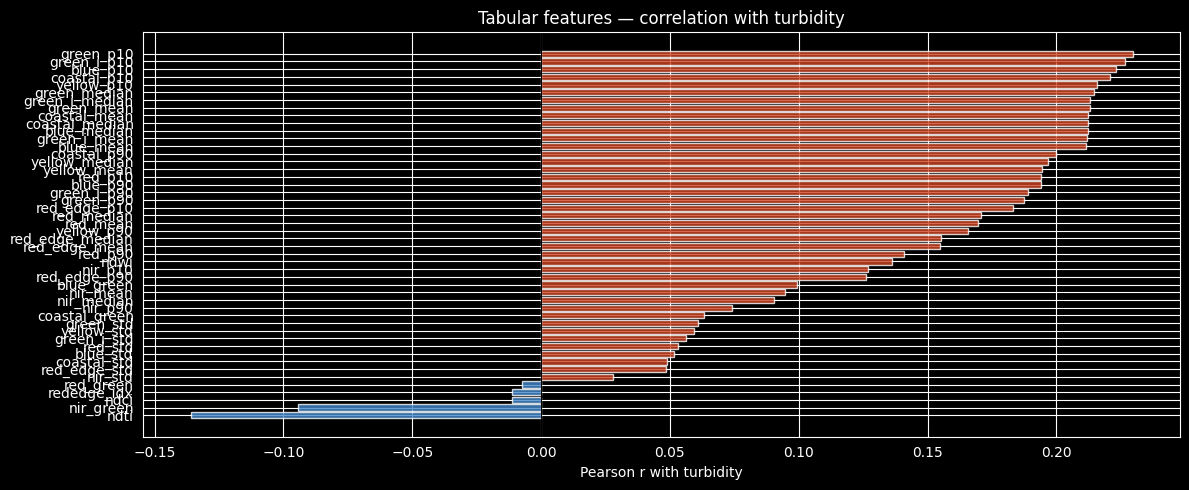

Top positive correlations:
 yellow_p10     0.215688
coastal_p10    0.220708
blue_p10       0.222971
green_i_p10    0.226473
green_p10      0.229692

Top negative correlations:
 ndti          -0.136053
nir_green     -0.094548
ndci          -0.011165
rededge_idx   -0.011165
red_green     -0.007419


In [10]:
import matplotlib.pyplot as plt

if tabular is not None:
    feat_cols = [c for c in tabular.columns if c not in META_COLS + ["n_pixels"]]
    corrs = tabular[feat_cols + ["turbidity"]].corr()["turbidity"].drop("turbidity").sort_values()

    fig, ax = plt.subplots(figsize=(12, 5))
    colours = ["#cc4422" if v > 0 else "#4488cc" for v in corrs]
    ax.barh(corrs.index, corrs.values, color=colours, alpha=0.8)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Pearson r with turbidity")
    ax.set_title("Tabular features — correlation with turbidity")
    plt.tight_layout()
    plt.show()

    top5_pos = corrs.tail(5)
    top5_neg = corrs.head(5)
    print("Top positive correlations:\n", top5_pos.to_string())
    print("\nTop negative correlations:\n", top5_neg.to_string())

### 1.4 Save tabular dataset

In [11]:
if tabular is not None:
    keep_cols = META_COLS + [c for c in tabular.columns if c not in META_COLS + ["n_pixels"]]
    tabular_out = tabular[keep_cols]
    out_path = FE_DIR / "fe_tabular.parquet"
    tabular_out.to_parquet(out_path, index=False)
    print(f"Saved {out_path.name}  shape={tabular_out.shape}")

Saved fe_tabular.parquet  shape=(423, 51)


---
## 2 · Band statistics from patches

Applies the same statistical aggregation as `02_data_preprocessing`, but now
computed from **patches** of different sizes rather than a fixed 200 m buffer.
This lets us study how the spatial integration window affects prediction quality.

For each of the five patch sizes:
1. Load patch array and merge labels
2. Compute per-band stats (mean, median, std, p10, p90) over valid circle pixels
3. Add spectral indices derived from band means
4. Save `fe_{N}px_stats.parquet`

In [12]:
patch_stats_cache = {}   # px → (X, meta) for reuse in later sections

for cfg in PATCH_CONFIGS:
    px       = cfg["px"]
    npz_path = PATCHES_DIR / f"patches_{px}px.npz"

    if not npz_path.exists():
        print(f"  {px}px — file not found, skipping")
        continue

    X, meta = load_patches(npz_path, df_y)
    patch_stats_cache[px] = (X, meta)

    stats_df = band_stats_from_patches(X, BAND_NAMES)
    stats_df = add_spectral_indices(stats_df)

    dataset  = pd.concat([meta.reset_index(drop=True),
                           stats_df.reset_index(drop=True)], axis=1)

    out_path = FE_DIR / f"fe_{px}px_stats.parquet"
    dataset.to_parquet(out_path, index=False)

    n_feat = stats_df.shape[1]
    print(f"  {cfg['metres']}  N={len(dataset):4d}  features={n_feat:3d}  → {out_path.name}")

  48  N= 419  features= 48  → fe_16px_stats.parquet
  96  N= 419  features= 48  → fe_32px_stats.parquet
  192  N= 419  features= 48  → fe_64px_stats.parquet
  384  N= 419  features= 48  → fe_128px_stats.parquet
  768  N= 419  features= 48  → fe_256px_stats.parquet


### 2.1 Analysis — how does turbidity correlation change with patch size?

For the green band mean (a key indicator of turbidity), we compare the Pearson r
with turbidity across all patch sizes. Larger patches include more spatial context
but may dilute the local signal near the CTD sensor.

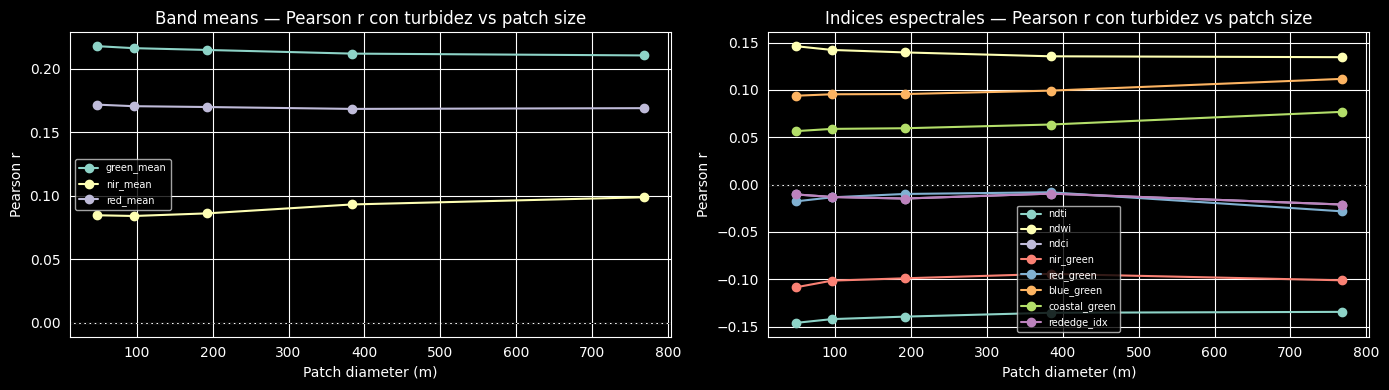

In [13]:
results = []

for cfg in PATCH_CONFIGS:
    px       = cfg["px"]
    npz_path = PATCHES_DIR / f"patches_{px}px.npz"
    if not npz_path.exists():
        continue
    X, meta = patch_stats_cache.get(px, (None, None))
    if X is None:
        continue

    stats_df = band_stats_from_patches(X, BAND_NAMES)
    stats_df = add_spectral_indices(stats_df)
    df_tmp   = pd.concat([meta[["turbidity"]].reset_index(drop=True),
                           stats_df.reset_index(drop=True)], axis=1)

    # Track band means + all spectral indices
    for band_col in ["green_mean", "nir_mean", "red_mean"] + INDEX_NAMES:
        if band_col in df_tmp.columns:
            r = df_tmp[[band_col, "turbidity"]].dropna().corr().iloc[0, 1]
            results.append({"patch_size_m": cfg["metres"], "feature": band_col, "pearson_r": r})

df_corr = pd.DataFrame(results)

# Separate band means from indices for cleaner plot
band_feats  = ["green_mean", "nir_mean", "red_mean"]
index_feats = INDEX_NAMES

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, feat_group, title in [
    (axes[0], band_feats,  "Band means — Pearson r con turbidez vs patch size"),
    (axes[1], index_feats, "Indices espectrales — Pearson r con turbidez vs patch size"),
]:
    for feat in feat_group:
        sub = df_corr[df_corr["feature"] == feat]
        if len(sub):
            ax.plot(sub["patch_size_m"], sub["pearson_r"], marker="o", label=feat)
    ax.axhline(0, color="black", lw=0.7, ls="--")
    ax.set_xlabel("Patch diameter (m)")
    ax.set_ylabel("Pearson r")
    ax.set_title(title)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

### 2.2 Análisis de índices espectrales

Para cada uno de los 8 índices:
- **Correlación con turbidez** (barplot, dataset de referencia = 64 px)
- **Distribución por cuartil de turbidez** (boxplots) — muestra si el índice separa bien niveles de turbidez
- **Scatterplot índice vs turbidez** (log-escala en y) — relación visual directa

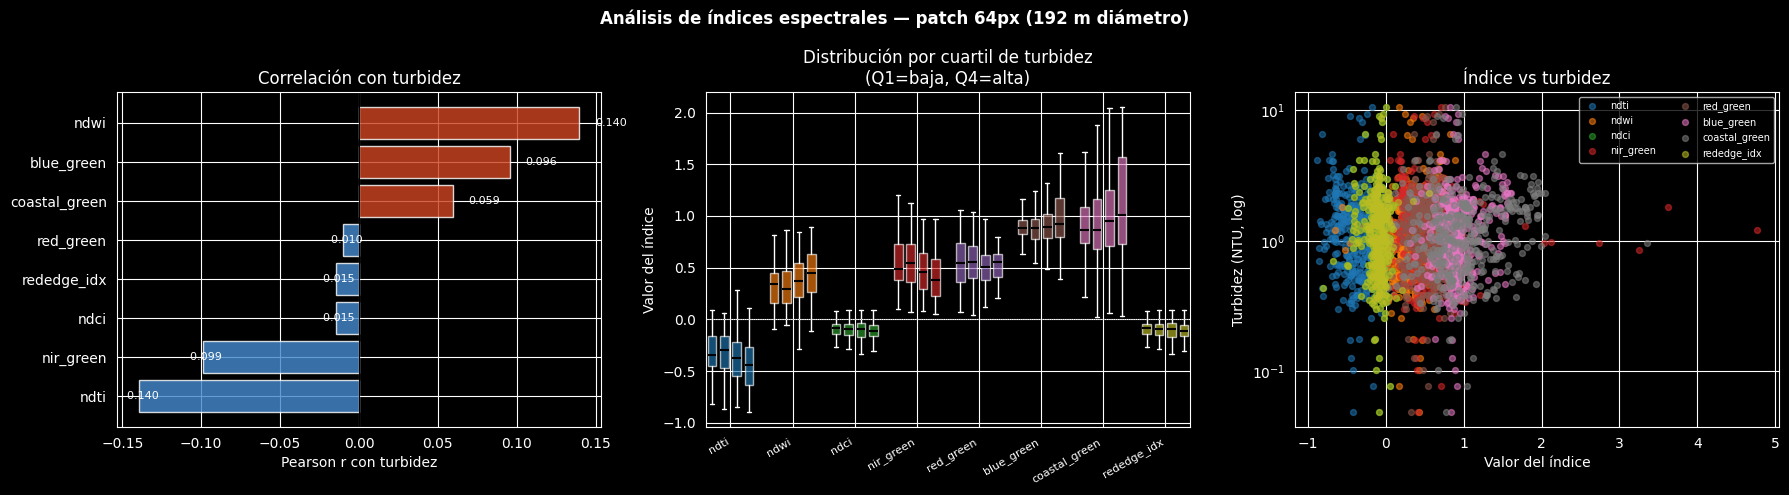

Resumen de índices espectrales (dataset ref: 64px):


,pearson_r,mean,std,min,max
ndwi,0.139565,0.3582,0.2410,-0.6534,0.8917
blue_green,0.095595,0.9262,0.2358,0.0434,1.6127
coastal_green,0.059461,0.9983,0.4448,0.0269,3.3487
red_green,-0.009963,0.5384,0.2043,0.0445,1.0795
ndci,-0.014802,-0.1090,0.1224,-0.8090,0.5506
rededge_idx,-0.014802,-0.1090,0.1224,-0.8090,0.5506
nir_green,-0.099069,0.5360,0.4129,0.0572,4.7697
ndti,-0.139565,-0.3582,0.2410,-0.8917,0.6534


In [14]:
ref_px = 64
if ref_px in patch_stats_cache:
    X_ref, meta_ref = patch_stats_cache[ref_px]
    stats_ref  = band_stats_from_patches(X_ref, BAND_NAMES)
    stats_ref  = add_spectral_indices(stats_ref)
    df_ref     = pd.concat([meta_ref[["turbidity"]].reset_index(drop=True),
                             stats_ref.reset_index(drop=True)], axis=1)

    # ── 1. Correlaciones ─────────────────────────────────────────────────────
    corrs = df_ref[INDEX_NAMES + ["turbidity"]].corr()["turbidity"].drop("turbidity")
    corrs_sorted = corrs.sort_values()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Análisis de índices espectrales — patch {ref_px}px ({ref_px*3} m diámetro)",
                 fontweight="bold")

    ax = axes[0]
    colours = ["#cc4422" if v > 0 else "#4488cc" for v in corrs_sorted]
    ax.barh(corrs_sorted.index, corrs_sorted.values, color=colours, alpha=0.82, edgecolor="white")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Pearson r con turbidez")
    ax.set_title("Correlación con turbidez")
    for i, (idx, val) in enumerate(corrs_sorted.items()):
        ax.text(val + 0.01 * np.sign(val), i, f"{val:.3f}", va="center", fontsize=8)

    # ── 2. Boxplots por cuartil ───────────────────────────────────────────────
    ax = axes[1]
    df_ref["turb_q"] = pd.qcut(df_ref["turbidity"], q=4,
                                labels=["Q1\n(baja)", "Q2", "Q3", "Q4\n(alta)"])
    n_idx  = len(INDEX_NAMES)
    xticks = []
    colors = plt.cm.tab10(np.linspace(0, 0.8, n_idx))

    for j, idx_name in enumerate(INDEX_NAMES):
        vals_by_q = [df_ref.loc[df_ref["turb_q"] == q, idx_name].dropna().values
                     for q in df_ref["turb_q"].cat.categories]
        positions = [j * 5 + k for k in range(4)]
        bp = ax.boxplot(vals_by_q, positions=positions, widths=0.7,
                        patch_artist=True, showfliers=False,
                        medianprops=dict(color="black", lw=1.5))
        for patch in bp["boxes"]:
            patch.set_facecolor(colors[j])
            patch.set_alpha(0.65)
        xticks.append((j * 5 + 1.5, idx_name))

    ax.set_xticks([x for x, _ in xticks])
    ax.set_xticklabels([n for _, n in xticks], rotation=30, ha="right", fontsize=8)
    ax.axhline(0, color="gray", lw=0.6, ls=":")
    ax.set_ylabel("Valor del índice")
    ax.set_title("Distribución por cuartil de turbidez\n(Q1=baja, Q4=alta)")

    # ── 3. Scatter: índice vs turbidez (log y) ────────────────────────────────
    ax = axes[2]
    cmap = plt.cm.tab10
    for j, idx_name in enumerate(INDEX_NAMES):
        sub = df_ref[["turbidity", idx_name]].dropna()
        ax.scatter(sub[idx_name], sub["turbidity"],
                   s=18, alpha=0.55, color=cmap(j / n_idx), label=idx_name)
    ax.set_yscale("log")
    ax.set_xlabel("Valor del índice")
    ax.set_ylabel("Turbidez (NTU, log)")
    ax.set_title("Índice vs turbidez")
    ax.legend(fontsize=7, ncol=2)

    plt.tight_layout()
    plt.show()

    # ── Tabla resumen ─────────────────────────────────────────────────────────
    summary_idx = pd.DataFrame({
        "pearson_r": corrs,
        "mean":      df_ref[INDEX_NAMES].mean().round(4),
        "std":       df_ref[INDEX_NAMES].std().round(4),
        "min":       df_ref[INDEX_NAMES].min().round(4),
        "max":       df_ref[INDEX_NAMES].max().round(4),
    }).sort_values("pearson_r", ascending=False)
    print("Resumen de índices espectrales (dataset ref: 64px):")
    display(summary_idx)

---
## 3 · Spatial texture features

Turbidity affects the spatial homogeneity of water reflectance:
- **High turbidity** → dense scattering → more uniform surface, low spatial gradients
- **Low turbidity** → sub-surface features visible → higher spatial heterogeneity

Three texture metrics per band are computed:

| Feature    | Description                                          |
|------------|------------------------------------------------------|
| `cv`       | Coefficient of variation = σ/μ (relative variability)|
| `grad_mean`| Mean Sobel gradient magnitude (spatial edges)        |
| `laplace_std` | Std of Laplacian (fine-texture strength / blurriness)|

Combined with band stats and spectral indices, this gives **69 features** per sample.

In [15]:
for cfg in PATCH_CONFIGS:
    px = cfg["px"]
    if px not in patch_stats_cache:
        print(f"  {px}px — not loaded, skipping"); continue

    X, meta = patch_stats_cache[px]

    stats_df   = band_stats_from_patches(X, BAND_NAMES)
    stats_df   = add_spectral_indices(stats_df)
    texture_df = compute_texture_features(X, BAND_NAMES)

    dataset = pd.concat([meta.reset_index(drop=True),
                          stats_df.reset_index(drop=True),
                          texture_df.reset_index(drop=True)], axis=1)

    out_path = FE_DIR / f"fe_{px}px_texture.parquet"
    dataset.to_parquet(out_path, index=False)

    n_feat = stats_df.shape[1] + texture_df.shape[1]
    print(f"  {cfg['metres']}  N={len(dataset):4d}  features={n_feat:3d}  → {out_path.name}")

  48  N= 419  features= 72  → fe_16px_texture.parquet
  96  N= 419  features= 72  → fe_32px_texture.parquet
  192  N= 419  features= 72  → fe_64px_texture.parquet
  384  N= 419  features= 72  → fe_128px_texture.parquet
  768  N= 419  features= 72  → fe_256px_texture.parquet


### 3.1 Analysis — texture vs turbidity

Do texture features add signal beyond band statistics?
Compare `grad_mean` (spatial gradient) across turbidity quartiles.

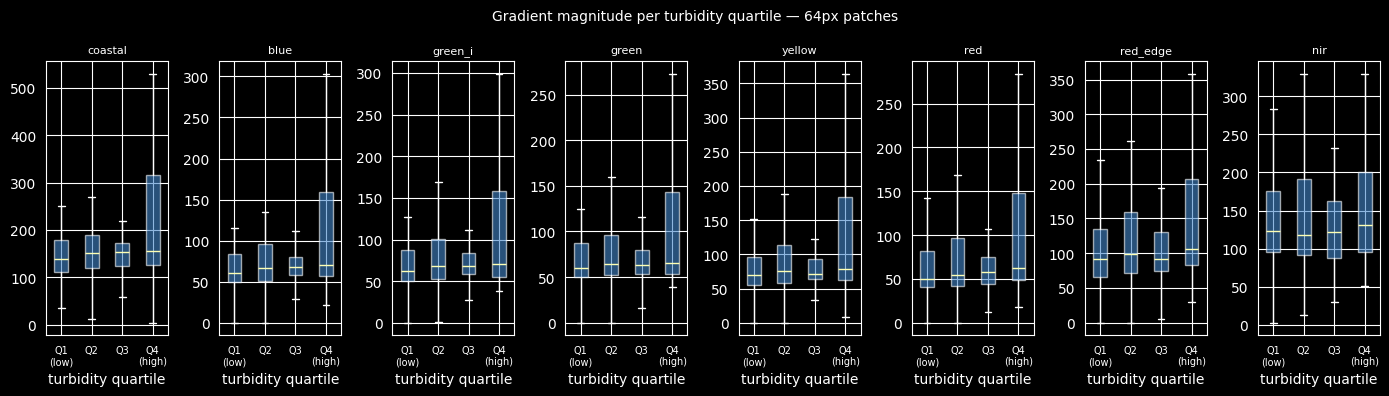

In [16]:
if patch_stats_cache:
    # Use 64 px as the reference size
    ref_px = 64
    if ref_px in patch_stats_cache:
        X, meta = patch_stats_cache[ref_px]
        texture_df = compute_texture_features(X, BAND_NAMES)
        df_tmp     = pd.concat([meta[["turbidity"]].reset_index(drop=True),
                                 texture_df.reset_index(drop=True)], axis=1)

        df_tmp["turb_q"] = pd.qcut(df_tmp["turbidity"], q=4,
                                    labels=["Q1\n(low)", "Q2", "Q3", "Q4\n(high)"])

        grad_cols = [c for c in df_tmp.columns if "grad_mean" in c]
        fig, axes = plt.subplots(1, len(grad_cols), figsize=(14, 4), sharey=False)
        fig.suptitle(f"Gradient magnitude per turbidity quartile — {ref_px}px patches",
                     fontsize=10)

        for ax, col in zip(axes if len(grad_cols) > 1 else [axes], grad_cols):
            data = [df_tmp.loc[df_tmp["turb_q"] == q, col].dropna().values
                    for q in df_tmp["turb_q"].cat.categories]
            bp = ax.boxplot(data, patch_artist=True, showfliers=False)
            for patch in bp["boxes"]:
                patch.set_facecolor("#4488cc"); patch.set_alpha(0.6)
            ax.set_xticklabels(df_tmp["turb_q"].cat.categories, fontsize=7)
            ax.set_title(col.replace("_grad_mean", ""), fontsize=8)
            ax.set_xlabel("turbidity quartile")

        plt.tight_layout()
        plt.show()

---
## 4 · PCA dimensionality reduction

The raw circular pixel vectors contain spatially-structured information that
simple statistics cannot capture, but their size grows quadratically with patch size.

**Strategy by patch size:**

| Size       | Raw features per sample | PCA approach              | Rationale                         |
|------------|-------------------------|---------------------------|-----------------------------------|
| 16 px      | 8 × 201 ≈ 1,608         | Global PCA (all bands)    | Small enough; cross-band spatial correlations important |
| 32 px      | 8 × 813 ≈ 6,504         | Global PCA (all bands)    | Still tractable                   |
| 64 px      | 8 × 3,217 ≈ 25,736      | Per-band PCA              | Global PCA too slow; per-band keeps interpretability |
| 128 px     | 8 × 12,869 ≈ 102,952    | Per-band PCA (≤20 comp.)  | Aggressive reduction needed       |
| 256 px     | 8 × 51,473 ≈ 411,784    | Per-band PCA (≤15 comp.)  | Only coarse spatial structure      |

Components retained: enough to explain ≥ 95 % of variance, capped at `pca_max_comp`.

NaN pixels within the circle (residual nodata) are imputed with the band mean
before PCA so that the input matrix has no missing values.

In [17]:
def extract_circle_pixels(X: np.ndarray, patch_px: int) -> np.ndarray:
    """
    Extract valid circle pixels from a batch of patches, imputing residual NaN.

    Parameters
    ----------
    X : (N, 8, px, px) float32

    Returns
    -------
    (N, 8 * n_circle_px) float32 — each row is a flat vector of circle pixels,
    band-by-band (all band-0 pixels, then all band-1 pixels, ...).
    """
    circle    = get_circle_mask(patch_px)   # (px, px) bool
    n_circ_px = circle.sum()
    N, B      = X.shape[0], X.shape[1]

    flat = np.zeros((N, B * n_circ_px), dtype=np.float32)
    for i in range(N):
        for b in range(B):
            v = X[i, b][circle]              # (n_circ_px,)
            nan_mask = np.isnan(v)
            if nan_mask.any():
                v[nan_mask] = np.nanmean(v)   # impute with band mean
            flat[i, b * n_circ_px:(b + 1) * n_circ_px] = v
    return flat


def fit_global_pca(X_flat: np.ndarray, max_comp: int, var_threshold: float = 0.95):
    """Fit PCA on all features jointly. Return (pca, n_components, explained_var)."""
    n_comp = min(max_comp, X_flat.shape[0] - 1, X_flat.shape[1])
    pca    = PCA(n_components=n_comp, random_state=42)
    pca.fit(X_flat)
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_keep = int(np.searchsorted(cumvar, var_threshold)) + 1
    n_keep = min(n_keep, n_comp)
    return pca, n_keep, cumvar


def fit_perband_pca(X: np.ndarray, patch_px: int, max_comp: int,
                    var_threshold: float = 0.95):
    """
    Fit one PCA per band on the circle pixels.

    Returns
    -------
    pcas      : list of fitted PCA objects (one per band)
    n_keeps   : list of int (components retained per band)
    cumvars   : list of cumulative variance arrays
    """
    circle    = get_circle_mask(patch_px)
    pcas, n_keeps, cumvars = [], [], []

    for b in range(X.shape[1]):
        band_flat = []
        for i in range(X.shape[0]):
            v = X[i, b][circle].copy()
            nan_mask = np.isnan(v)
            if nan_mask.any():
                v[nan_mask] = np.nanmean(v)
            band_flat.append(v)
        band_flat = np.stack(band_flat)   # (N, n_circ_px)

        n_comp = min(max_comp, band_flat.shape[0] - 1, band_flat.shape[1])
        pca    = PCA(n_components=n_comp, random_state=42)
        pca.fit(band_flat)
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        n_keep = int(np.searchsorted(cumvar, var_threshold)) + 1
        n_keep = min(n_keep, n_comp)

        pcas.append(pca); n_keeps.append(n_keep); cumvars.append(cumvar)

    return pcas, n_keeps, cumvars

In [18]:
pca_summary = []   # for the scree-plot cell

for cfg in PATCH_CONFIGS:
    px       = cfg["px"]
    strategy = cfg["pca_strategy"]
    max_comp = cfg["pca_max_comp"]

    if px not in patch_stats_cache:
        print(f"  {px}px — not loaded, skipping"); continue

    X, meta = patch_stats_cache[px]
    print(f"\n--- {cfg['metres']} | strategy: {strategy} ---")

    if strategy == "global":
        X_flat           = extract_circle_pixels(X, px)
        pca, n_keep, cv  = fit_global_pca(X_flat, max_comp)

        X_pca = pca.transform(X_flat)[:, :n_keep]
        col_names = [f"pca_{i}" for i in range(n_keep)]

        pca_summary.append({
            "px": px, "strategy": strategy,
            "raw_features": X_flat.shape[1],
            "components_kept": n_keep,
            "var_explained": float(cv[n_keep - 1]),
        })
        print(f"  Global PCA: {X_flat.shape[1]:,} → {n_keep} components "
              f"({100*cv[n_keep-1]:.1f}% variance)")

    else:  # per_band
        circle    = get_circle_mask(px)
        pcas, n_keeps, cumvars = fit_perband_pca(X, px, max_comp)

        band_parts = []
        for b in range(X.shape[1]):
            band_flat = []
            for i in range(X.shape[0]):
                v = X[i, b][circle].copy()
                nan_mask = np.isnan(v)
                if nan_mask.any():
                    v[nan_mask] = np.nanmean(v)
                band_flat.append(v)
            band_flat  = np.stack(band_flat)
            part       = pcas[b].transform(band_flat)[:, :n_keeps[b]]
            band_parts.append(part)

        X_pca     = np.concatenate(band_parts, axis=1)
        col_names = []
        for b, name in enumerate(BAND_NAMES):
            col_names += [f"{name}_pc{i}" for i in range(n_keeps[b])]

        total_raw  = sum(circle.sum() for _ in range(8))
        total_kept = X_pca.shape[1]
        mean_var   = float(np.mean([cv[n - 1] for cv, n in zip(cumvars, n_keeps)]))

        pca_summary.append({
            "px": px, "strategy": strategy,
            "raw_features": total_raw,
            "components_kept": total_kept,
            "var_explained": mean_var,
        })
        print(f"  Per-band PCA: {total_raw:,} → {total_kept} components "
              f"(mean {100*mean_var:.1f}% variance per band)")

    dataset = pd.concat([meta.reset_index(drop=True),
                          pd.DataFrame(X_pca, columns=col_names)], axis=1)

    out_path = FE_DIR / f"fe_{px}px_pca.parquet"
    dataset.to_parquet(out_path, index=False)
    print(f"  Saved → {out_path.name}  shape={dataset.shape}")


--- 48 | strategy: global ---
  Global PCA: 1,664 → 1 components (97.3% variance)
  Saved → fe_16px_pca.parquet  shape=(419, 4)

--- 96 | strategy: global ---
  Global PCA: 6,496 → 1 components (97.1% variance)
  Saved → fe_32px_pca.parquet  shape=(419, 4)

--- 192 | strategy: per_band ---
  Per-band PCA: 25,824 → 8 components (mean 98.1% variance per band)
  Saved → fe_64px_pca.parquet  shape=(419, 11)

--- 384 | strategy: per_band ---
  Per-band PCA: 103,136 → 12 components (mean 97.1% variance per band)
  Saved → fe_128px_pca.parquet  shape=(419, 15)

--- 768 | strategy: per_band ---
  Per-band PCA: 411,744 → 19 components (mean 96.8% variance per band)
  Saved → fe_256px_pca.parquet  shape=(419, 22)


### 4.1 Scree plots — explained variance per patch size

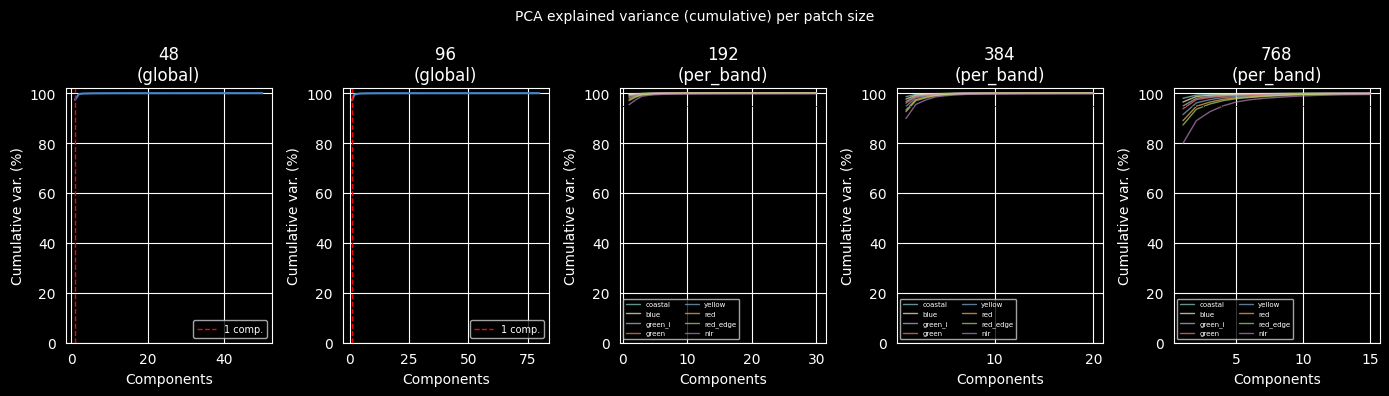

In [19]:
if patch_stats_cache:
    fig, axes = plt.subplots(1, len(PATCH_CONFIGS), figsize=(14, 4))
    fig.suptitle("PCA explained variance (cumulative) per patch size", fontsize=10)

    for ax, cfg in zip(axes if len(PATCH_CONFIGS) > 1 else [axes], PATCH_CONFIGS):
        px       = cfg["px"]
        strategy = cfg["pca_strategy"]
        max_comp = cfg["pca_max_comp"]

        if px not in patch_stats_cache:
            ax.set_title(f"{px}px\n(no data)"); ax.axis("off"); continue

        X, _ = patch_stats_cache[px]

        if strategy == "global":
            X_flat = extract_circle_pixels(X, px)
            _, n_keep, cumvar = fit_global_pca(X_flat, max_comp)
            ax.plot(range(1, len(cumvar) + 1), cumvar * 100, lw=1.5, color="#4488cc")
            ax.axvline(n_keep, color="red", lw=1, ls="--", label=f"{n_keep} comp.")
        else:
            pcas, n_keeps, cumvars = fit_perband_pca(X, px, max_comp)
            for b, (name, cv, nk) in enumerate(zip(BAND_NAMES, cumvars, n_keeps)):
                ax.plot(range(1, len(cv) + 1), cv * 100, lw=1, alpha=0.7, label=name)
            ax.axhline(95, color="black", lw=0.7, ls=":")

        ax.set_xlabel("Components")
        ax.set_ylabel("Cumulative var. (%)")
        ax.set_title(f"{cfg['metres']}\n({strategy})")
        ax.set_ylim(0, 102)
        if strategy == "global":
            ax.legend(fontsize=7)
        else:
            ax.legend(fontsize=5, ncol=2)

    plt.tight_layout()
    plt.show()

---
## 5 · Summary of generated datasets

In [20]:
summary_rows = []

for f in sorted(FE_DIR.glob("*.parquet")):
    df_tmp = pd.read_parquet(f, columns=None)
    feat_cols = [c for c in df_tmp.columns if c not in META_COLS]
    summary_rows.append({
        "file":            f.name,
        "samples":         len(df_tmp),
        "features":        len(feat_cols),
        "has_turbidity":   "turbidity" in df_tmp.columns,
        "nan_fraction":    df_tmp[feat_cols].isna().mean().mean().round(4),
    })

summary = pd.DataFrame(summary_rows).set_index("file")
print(f"Total datasets generated: {len(summary)}")
summary

Total datasets generated: 16


,samples,features,has_turbidity,nan_fraction
file,,,,
fe_128px_pca.parquet,419,12,True,0.0
fe_128px_stats.parquet,419,48,True,0.0
fe_128px_texture.parquet,419,72,True,0.0
fe_16px_pca.parquet,419,1,True,0.0
fe_16px_stats.parquet,419,48,True,0.0
fe_16px_texture.parquet,419,72,True,0.0
fe_256px_pca.parquet,419,19,True,0.0
fe_256px_stats.parquet,419,48,True,0.0
fe_256px_texture.parquet,419,72,True,0.0
